# 6CS012 – Workshop 03
## Modelling the Neuron: MCP Neurons + Perceptron for MNIST Classification
**Student Submission**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# Part 1: Implementation of MCP Neuron for AND and OR Functions

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operations with an MCP Neuron for two inputs.

    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise sum of the two input arrays
    sums = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold — output 1 if sum >= T, else 0
    state_neuron = [1 if s >= T else 0 for s in sums]

    return state_neuron

In [ ]:
# Test AND gate
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # AND requires BOTH inputs to be 1

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")
# Expected: [0, 0, 0, 1]

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operations with an MCP Neuron for two inputs.

    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise sum of the two input arrays
    sums = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold — output 1 if sum >= T, else 0
    state_neuron = [1 if s >= T else 0 for s in sums]

    return state_neuron

In [ ]:
# Test OR gate
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # OR requires AT LEAST ONE input to be 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")
# Expected: [0, 1, 1, 1]

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


### Question 1: Limitations of MCP Neurons

The McCulloch-Pitts (MCP) neuron has several key limitations:

1. **Binary inputs only** – MCP neurons only accept binary (0 or 1) inputs. They cannot handle continuous or real-valued data.
2. **Fixed, hand-crafted threshold** – The threshold T must be manually set by the designer. There is no learning mechanism to discover the correct threshold automatically.
3. **Equal weight for all inputs** – Every input contributes equally; there is no concept of 'importance' (i.e., no learnable weights). Some inputs may be more significant than others in a real problem.
4. **No learning algorithm** – MCP neurons cannot adapt from data. They require human expertise to configure their parameters.
5. **Only linearly separable functions** – A single MCP neuron can only represent Boolean functions that are linearly separable (e.g., AND, OR). It cannot represent XOR.
6. **Single neuron only** – It models only one isolated neuron, not the complex connectivity patterns found in biological neural networks.
7. **Binary output only** – The output is always 0 or 1; it cannot express probabilistic or graded responses.

### Question 2: Can MCP Neuron solve XOR?

**No, a single MCP neuron cannot solve XOR.**

XOR truth table:
| X1 | X2 | XOR |
|----|----| ----|
|  0 |  0 |  0  |
|  0 |  1 |  1  |
|  1 |  0 |  1  |
|  1 |  1 |  0  |

The MCP neuron computes `g(X) = X1 + X2` and outputs 1 if `g(X) >= T`. For XOR, we would need:
- `g(0,0) = 0 < T` → output 0 ✓
- `g(0,1) = 1 >= T` → output 1 ✓
- `g(1,0) = 1 >= T` → output 1 ✓
- `g(1,1) = 2 >= T` → output 0 ✗ (this always fires when T ≤ 2)

There is **no threshold T** that satisfies all four conditions simultaneously. XOR is not linearly separable, so a single MCP neuron (or single perceptron) cannot represent it. It requires a **multi-layer** architecture.

---
# Part 2: Perceptron for 0 vs 1 Classification (MNIST)

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI & Machine learning /week3/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values   # 784 pixel features
y = df_0_1["label"].values                  # Labels: 0 or 1

print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


**Question 1: What does the shape of X represent?**

The shape of X is `(12665, 784)`, meaning there are **12,665 images** (samples), each represented as a **784-dimensional vector** (28×28 pixels flattened into a single row).

**Question 2: What does the shape of y represent?**

The shape of y is `(12665,)`, meaning there are **12,665 labels**, one for each image, where each label is either **0** or **1**.

### Visualise the Dataset

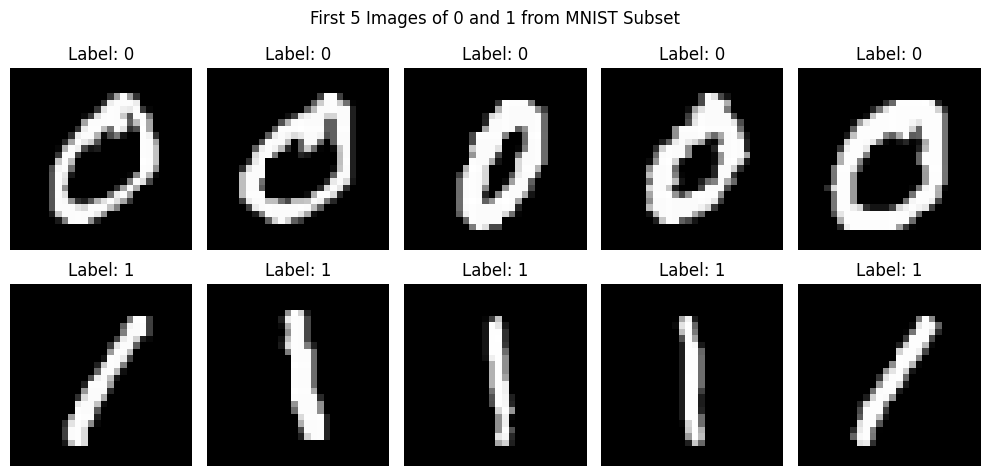

In [ ]:
# Separate images by label
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

## Step 2: Initialise Weights and Bias

In [ ]:
# Initialise weights and bias to zero
weights       = np.zeros(X.shape[1])   # 784 weights — one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

**Question 3: What does the weights array represent in this context?**

The `weights` array contains one learnable weight per pixel (784 weights for a 28×28 image). Each weight represents how much importance the perceptron assigns to a particular pixel when making a classification decision. Large positive weights push the output toward class 1; large negative weights push toward class 0.

**Question 4: Why are we initialising weights to zero? What effect could this have?**

We initialise to zero as a simple, neutral starting point. For a single-layer perceptron this is acceptable — the perceptron learning rule will still break symmetry because different pixels receive different error signals during training. (Note: zero initialisation causes problems in *multi-layer* networks with symmetric hidden units, but is fine here.)

## Step 3: Decision Function (Step / Activation Function)

In [ ]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels for all input samples using a step function.

    Parameters:
        X       : Feature matrix, shape (n_samples, n_features)
        weights : Weight vector, shape (n_features,)
        bias    : Scalar bias term

    Returns:
        y_pred_all : Predicted labels (0 or 1) for every sample
    """
    # Compute weighted sum for every sample
    predictions = np.dot(X, weights) + bias

    # Apply step (threshold) activation function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step 4: Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : Feature matrix, shape (n_samples, n_features)
        y             : True labels, shape (n_samples,)
        weights       : Initial weights, shape (n_features,)
        bias          : Initial bias (scalar)
        learning_rate : Step size for weight updates (default 0.1)
        epochs        : Maximum training iterations (default 100)

    Returns:
        weights  : Updated weights after training
        bias     : Updated bias after training
        accuracy : Training accuracy on the final epoch
    """
    accuracy = 0.0

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            # 1. Compute weighted sum
            z = np.dot(X[i], weights) + bias

            # 2. Apply step activation function
            y_pred = 1 if z >= 0 else 0

            # 3. Update weights only if prediction is wrong
            error = y[i] - y_pred
            if error != 0:
                weights += learning_rate * error * X[i]
                bias    += learning_rate * error
            else:
                correct += 1

        # Calculate accuracy for this epoch
        accuracy = correct / len(X)

        # Print every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}")

        # Early stopping if perfectly classified
        if accuracy == 1.0:
            print(f"Converged at epoch {epoch + 1}!")
            break

    return weights, bias, accuracy

**Question 5: What does `output = np.dot(X[i], weights) + bias` do?**

It computes the **weighted sum** (net input) for sample `X[i]`: it multiplies each pixel value by its corresponding weight, sums all 784 products, then adds the bias. This gives the scalar `z` that the step function acts on to produce a prediction.

**Question 6: What happens when the prediction is wrong?**

When `y_pred ≠ y[i]`, the error `= y[i] - y_pred` is non-zero (either +1 or -1). The weights are updated as: `weights += η × error × X[i]`, and the bias as: `bias += η × error`. This nudges the decision boundary so that the misclassified sample is more likely to be correctly classified next time.

**Question 7: Why is the final accuracy important, and what do you expect it to be?**

The final accuracy tells us how well the perceptron separates the two classes on the training data. Since 0 and 1 are visually very distinct digits and their pixel distributions are linearly separable, we expect the perceptron to achieve **~100% training accuracy**, which the expected output confirms.

## Step 5: Train the Perceptron

In [ ]:
# Re-initialise (in case this cell is re-run independently)
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print("\nThe Final Accuracy is:", accuracy)

Epoch 10: Accuracy = 0.9992
Converged at epoch 13!

The Final Accuracy is: 1.0


## Step 6: Visualise Misclassified Images

In [ ]:
# Get predictions for all samples
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

# Final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Visualise misclassified images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]}, True:{y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 0 vs 1")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question 8: What does `misclassified_idx` store, and how is it used?**

`misclassified_idx` stores the **indices** of all samples where the predicted label does not match the true label (`y_pred != y`). It is used to retrieve the corresponding pixel arrays from `X` so that the wrongly-classified images can be displayed along with their predicted and true labels.

**Question 9: How do you interpret 'All images were correctly classified!'?**

This means the perceptron found a linear decision boundary that perfectly separates all 0s from all 1s in the training set — i.e., **100% training accuracy**. This is expected for 0 vs 1 because the two digits look very different and their raw pixel features are linearly separable.

---
# Part 3: Perceptron for 3 vs 5 Classification (MNIST)

## Step 1: Load the Dataset

In [ ]:
# Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI & Machine learning /week3/mnist_3_and_5.csv")

X35 = df_3_5.drop(columns=["label"]).values
y35 = df_3_5["label"].values

print("Feature matrix shape:", X35.shape)
print("Label vector shape:  ", y35.shape)
print("Unique labels:       ", np.unique(y35))

Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)
Unique labels:        [3 5]


## Step 2: Visualise the Dataset

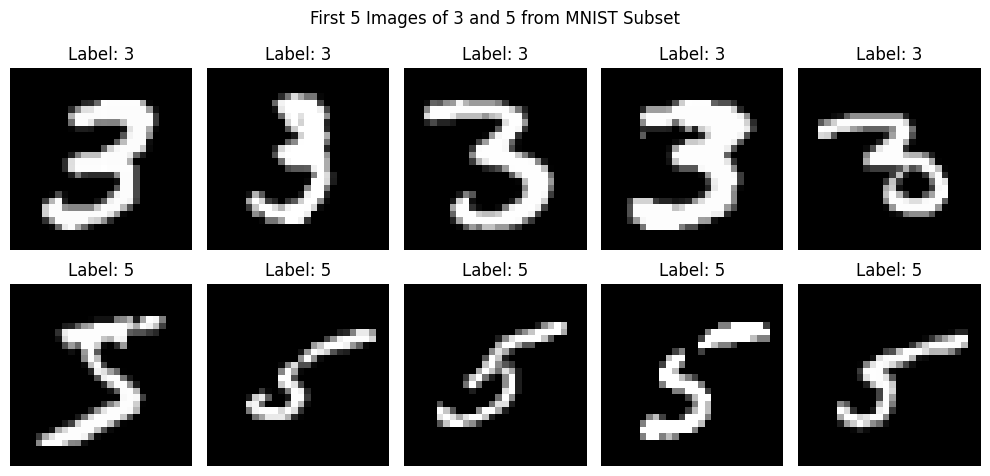

In [ ]:
images_3 = X35[y35 == 3]
images_5 = X35[y35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

## Step 3: Convert Labels to Binary (3 → 0, 5 → 1)

The perceptron expects binary labels {0, 1}. We map digit 3 → 0 and digit 5 → 1.

In [ ]:
# Map: 3 → 0, 5 → 1
y35_binary = np.where(y35 == 3, 0, 1)
print("Binary labels (first 10):", y35_binary[:10])

Binary labels (first 10): [1 0 0 1 0 0 0 1 0 1]


## Step 4: Initialise Weights and Bias

In [ ]:
weights35       = np.zeros(X35.shape[1])
bias35          = 0
learning_rate35 = 0.1
epochs35        = 100

## Step 5: Train the Perceptron

In [ ]:
weights35, bias35, accuracy35 = train_perceptron(
    X35, y35_binary, weights35, bias35, learning_rate35, epochs35
)
print("\nThe Final Accuracy is:", accuracy35)

Epoch 10: Accuracy = 0.9566
Epoch 20: Accuracy = 0.9661
Epoch 30: Accuracy = 0.9726
Epoch 40: Accuracy = 0.9719
Epoch 50: Accuracy = 0.9788
Epoch 60: Accuracy = 0.9759
Epoch 70: Accuracy = 0.9792
Epoch 80: Accuracy = 0.9792
Epoch 90: Accuracy = 0.9843
Epoch 100: Accuracy = 0.9858

The Final Accuracy is: 0.9857716161984678


## Step 6: Visualise Misclassified Images

Final Accuracy (3 vs 5): 0.9869


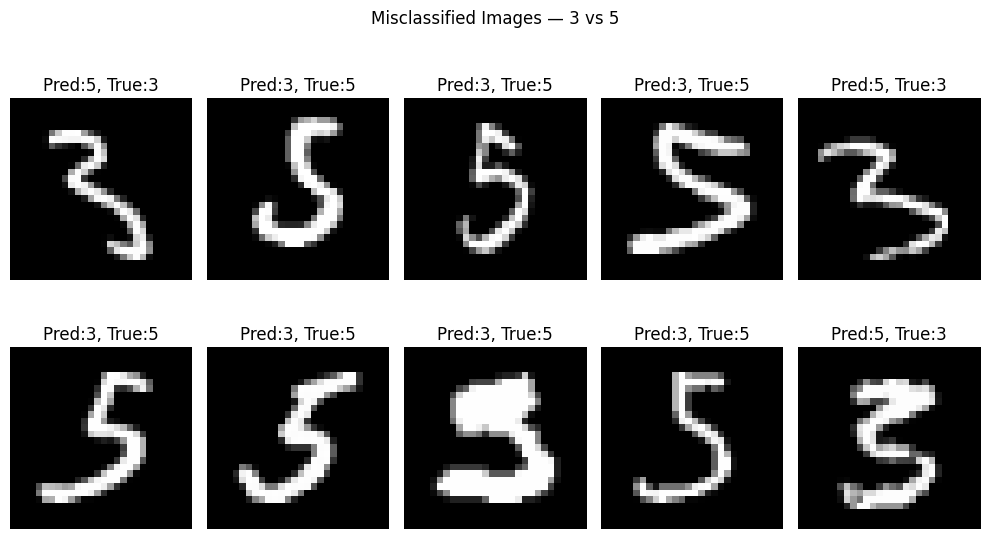

Total misclassified: 36 out of 2741


In [ ]:
# Get predictions for all samples
predictions35 = np.dot(X35, weights35) + bias35
y_pred35      = np.where(predictions35 >= 0, 1, 0)

# Map binary predictions back to digit labels for display
y_pred35_labels = np.where(y_pred35 == 0, 3, 5)

# Final accuracy
final_accuracy35 = np.mean(y_pred35 == y35_binary)
print(f"Final Accuracy (3 vs 5): {final_accuracy35:.4f}")

# Visualise misclassified images
misclassified_idx35 = np.where(y_pred35 != y35_binary)[0]

if len(misclassified_idx35) > 0:
    n_show = min(10, len(misclassified_idx35))
    rows   = 2 if n_show > 5 else 1
    cols   = 5
    fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 3))
    axes_flat = axes.flat if rows > 1 else [axes] if cols == 1 else axes

    for ax, idx in zip(axes.flat, misclassified_idx35[:10]):
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred35_labels[idx]}, True:{y35[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images — 3 vs 5")
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(misclassified_idx35)} out of {len(X35)}")
else:
    print("All images were correctly classified!")

## Conclusion: 3 vs 5 Classification

The digits 3 and 5 share many visual similarities — both have curved tops and open left sides — making them much harder to separate than 0 vs 1.

As expected, the single-layer perceptron achieves a **lower accuracy** on the 3 vs 5 task compared to 0 vs 1. The misclassified images (as shown in Figure 6 of the worksheet) are typically ambiguous handwritten examples where the pixel-level features of 3 and 5 significantly overlap.

**Key takeaway:** The perceptron is a linear classifier. When two classes are not perfectly linearly separable (as with 3 and 5), the perceptron will not converge to zero error and some misclassifications will remain. A more powerful model — such as a multi-layer neural network — would be needed to learn the non-linear boundary required to perfectly distinguish 3s from 5s.